In [1]:
from astropy.table import Table, join

from astropy import units as u

import numpy as np

import matplotlib.pyplot as plt

import astropy.constants as const

In [8]:
c = const.c.to('km/s')
G = const.G
#Reduced Hubble Constant (km/s/Mpc)
H0 = 100 * u.km / u.s / u.Mpc

In [3]:
loa_rotvel = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel_curvefit.fits')
loa_rotvel[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_RR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI,rot_vel_filing,r_kpc,chi2_reduced,vmax_fit,rturn_fit,vmax_err,rturn_err
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64
169678387281926,1430874,257.7495971,56.9324928,0.028921517883227336,0.028921517883227336,0,121857.89663615823,0.003250448915035935,0.31250071154567677,6.557606220245361,206.22810010342067,199.6704938831753,1,2.4024789259983957e-05,3.0,182.8750198451699,11.489101308260244,2.401212431981059e-05,0,0.008096415535868652,0.7783957484224773,0,0,0.20122416188287864,0.38706405138543304,188.0016333989227,0.004035780336833629,145.11961827963177,4.09983872988525
243323033878571,631434,151.0147419137485,1.6331543609904198,1.3809988331159857,1.3809988331159857,4,0.7242707014083862,0.0057124407591539585,0.9175586924842383,51.69132614135742,32.48938717521324,19.201938966144183,1,5.5595100500533275e-05,8.0,472239.65646196203,24.11477245431036,1.7258340278094598e-05,0,0.006601088916040368,1.0602974753074295,0,0,0.26035704174416274,--,--,--,145.11961827963177,4.09983872988525
1004815400304641,188925,193.6701,28.93758,0.0082724267277799,0.0082724267277799,0,20781.262633197082,0.0009923137447555642,0.026284859154548004,48.5860481262207,146.26021571620655,97.67416758998584,2,2.3542643581428787e-05,31.0,-181.63274387448345,72.81809787647651,1.6648346838273807e-05,0,0.0011151277859353821,0.02953801350383857,0,0,0.008088028889852567,5.63436883524322,170.25925589571688,0.03525810913705583,145.11961827963177,4.09983872988525
1005093910478848,1309576,234.30175,43.3014166667,0.019607169071382585,0.019607169071382585,0,21025.242969959974,0.004020441905483598,0.2179634595949638,134.6117401123047,320.7967839323471,186.18504382004244,1,2.380730399661915e-05,8.0,173.70559603525007,12.904304444072334,2.3796769180937358e-05,0,0.005374691904048404,0.2913825069989467,0,0,0.08955195966842268,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525
1005093910478849,1309576,234.303916667,43.2961944444,0.0190429075748926,0.0190429075748926,0,37842.76546475291,0.0023170693385198464,0.12561714881549862,134.6117401123047,204.59833750241611,69.98659739011143,1,2.3794128780331918e-05,8.0,-126.47090634603123,37.70665102866408,2.3796769180937358e-05,0,0.0031473131687750006,0.1706278271946506,0,0,0.05243985459735577,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525


In [26]:
SGA = Table.read('/pscratch/sd/d/dbustos/rot_curves/sga_total_mass.fits')

In [27]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

In [28]:
new_table = loa_rotvel[np.isfinite(loa_rotvel['vmax_fit']) & np.isfinite(loa_rotvel['vmax_err'])]

In [29]:
print(G)

  Name   = Gravitational constant
  Value  = 6.6743e-11
  Uncertainty  = 1.5e-15
  Unit  = m3 / (kg s2)
  Reference = CODATA 2022


In [30]:
# new_table['l10_mass'] = np.nan
SGA['new_mass'] = np.nan
SGA['vmax'] = np.nan

for i in np.unique(new_table['SGA_ID']):

    fibers = new_table['SGA_ID'] == i

    sga_id = SGA_dict[i]

    targs = new_table[fibers]
    
    vmax = targs['vmax_fit'][0] * u.km/u.s

    rturn = targs['rturn_fit'][0] * u.kpc

    r26_dist = .5 * SGA[sga_id]['D26']
    
    # distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0 

    # convert deprojected dist from arcmin to radians
    theta = np.radians(r26_dist/60)

    # real distance from center of galaxy to fiber in units kpc/h
    r_fiber = (d_center * np.tan(theta))

    # print(np.tanh((r_fiber.to('kpc')/rturn)*u.rad))
    
    # get vrot from fit params
    v_rot = vmax * np.tanh((r_fiber.to('kpc')/rturn)*u.rad)
    
    #total mass and log total mass
    mass = (v_rot.to('m/s')**2)*(r_fiber.to('m'))/G
    # print(mass)
    # break
    
    log_mass = np.log10(mass/const.M_sun)
    # print(log_mass)
    # break


    # # stellar mass
    # cg_mass = SGA['MASS_CG_5'][sga_id]
    # log_cg =  np.log10(cg_mass)

    # # HI mass
    # HI_mass = SGA['logMH_alf'][sga_id]

    SGA['new_mass'][sga_id] = log_mass
    SGA['vmax'][sga_id] = vmax.value
    

    # SGA['log_cgmass'][sga_id] = log_cg

    # new_table['l10_mass'][fibers] = log_mass

/global/common/software/nersc/pe/conda-envs/26.8.0/python-3.13/nersc-python/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/common/software/nersc/pe/conda-envs/26.8.0/python-3.13/nersc-python/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/common/software/nersc/pe/conda-envs/26.8.0/python-3.13/nersc-python/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/common/software/nersc/pe/conda-envs/26.8.0/python-3.13/nersc-python/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(f

In [31]:
stellar_mask = np.isfinite(SGA['log_cgmass']) & np.isfinite(SGA['new_mass'])
total_stellar = SGA['SGA_ID','new_mass', 'log_cgmass', 'vmax'][stellar_mask]
total_stellar[:5]

SGA_ID,new_mass,log_cgmass,vmax
int64,float64,float64,float64
187,10.348826874435494,9.137871600225193,96.12227404914776
353,11.563572713395136,10.618869428596875,262.26417257062775
484,11.310653254041902,10.852956102526427,194.90421268758948
566,10.625496965437167,9.81699332959007,124.5269739700841
1548,11.212281588127677,10.211589179408568,219.2681880461743


In [32]:
HI_mask = (~SGA['logMH_alf'].mask) & np.isfinite(SGA['new_mass'])
total_HI = SGA['SGA_ID','new_mass', 'logMH_alf','vmax'][HI_mask]
total_HI[:5]

SGA_ID,new_mass,logMH_alf,vmax
int64,float64,float64,float64
566,10.625496965437167,9.85,124.5269739700841
3278,10.711666302855381,10.01,183.04494190712603
6669,9.45233653329842,10.06,38.812336620194706
7880,11.242476920479069,9.37,195.07363736357908
8281,10.102257754563295,9.58,94.73012180494318


In [33]:
alf_cig = (~SGA['logMH_alf'].mask) & np.isfinite(SGA['log_cgmass'])
test = SGA['SGA_ID','logMH_alf', 'log_cgmass', 'new_mass','vmax'][alf_cig]
test[:5]

SGA_ID,logMH_alf,log_cgmass,new_mass,vmax
int64,float64,float64,float64,float64
566,9.85,9.81699332959007,10.625496965437167,124.5269739700841
3278,10.01,9.997212207457382,10.711666302855381,183.04494190712603
6669,10.06,9.868183955538365,9.45233653329842,38.812336620194706
8281,9.58,9.33114068021977,10.102257754563295,94.73012180494318
12681,9.71,9.94517002438873,10.727906353439124,166.00306749181055


In [34]:
y = np.log10(10**(test['logMH_alf'])+10**(test['log_cgmass']))

Text(0.5, 0, 'Total Mass within $R_{26}$  $[log(M/M_\\odot)]$')

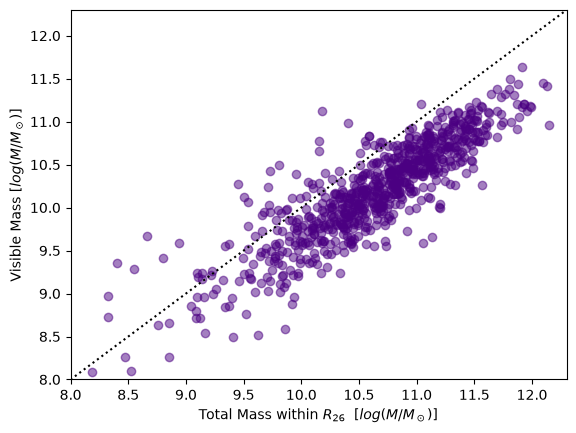

In [35]:
fig, ax = plt.subplots()

ax.scatter(test['new_mass'], y, alpha = .5, c = 'indigo')
ax.plot([7.5,15.5],[7.5,15.5],'k:')

# ax.set_ylim(7.8,12)
ax.set_xlim(8, 12.3)
ax.set_ylim(8, 12.3)


# ax.scatter(total_stellar['log_cgmass'], total_stellar['total_mass'], alpha = .7, c = 'indigo')
# ax.scatter(total_HI['logMH_alf'], total_HI['total_mass'], alpha = .7, c = 'lightseagreen')

# ax.scatter(test['log_cgmass'], test['logMH_alf'])
# ax.legend(['Stellar Mass', 'HI Mass'])

ax.set_ylabel(r'Visible Mass $[log(M/M_\odot)]$')
ax.set_xlabel(r'Total Mass within $R_{26}$  $[log(M/M_\odot)]$')
# ax.set_title('Stellar/HI Mass vs $R_{26}$ $Mass$')

# fig.savefig('/Users/daniel/Downloads/mass_plot_2', dpi=120)

Text(0.5, 0, 'Rotational Velocity $[log(km/s)]$')

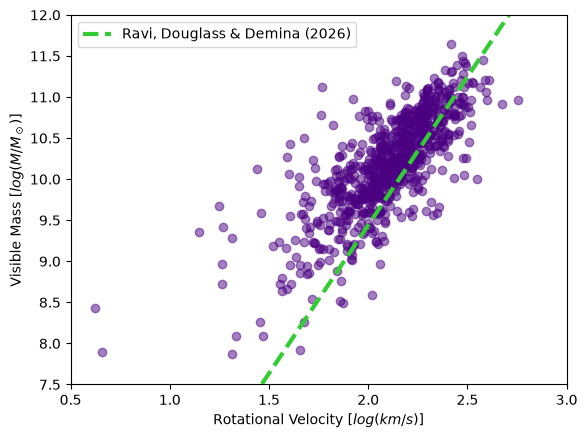

In [36]:
fig, ax = plt.subplots()

ax.scatter(np.log10(test['vmax']), y, alpha = .5, c = 'indigo')

x = np.linspace(0,3,100)

ax.plot(x,(3.61 * x) + 2.22, ls = '--',lw = 3, c= 'limegreen', label = 'Ravi, Douglass & Demina (2026)')

upper = (3.61+1.7)*x + (2.22+1.96)
lower = (3.61-.87)*x + (2.22-3.89)
# ax.fill_between(x, upper, lower, alpha = .1, color = 'lightseagreen') 

ax.set_ylim(7.5,12)
ax.set_xlim(0.5, 3)

ax.legend()


# ax.scatter(total_stellar['log_cgmass'], total_stellar['total_mass'], alpha = .7, c = 'indigo')
# ax.scatter(total_HI['logMH_alf'], total_HI['total_mass'], alpha = .7, c = 'lightseagreen')

# ax.scatter(test['log_cgmass'], test['logMH_alf'])
# ax.legend(['Stellar Mass', 'HI Mass'])

ax.set_ylabel(r'Visible Mass $[log(M/M_\odot)]$')
ax.set_xlabel(r'Rotational Velocity $[log(km/s)]$')
# ax.set_title('Stellar/HI Mass vs $R_{26}$ $Mass$')

# fig.savefig('/Users/daniel/Downloads/BTF_1', dpi=120)